# **EfficientNet Pre-trained Binary Model with Raw Input**

In this notebook we test a pre-trained EfficientNet model to predict Animal vs Non-animal. For this, the original images were used.

## Libraries

In [1]:
# import os
# os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

In [2]:
# Libraries
import pandas as pd

from deep.constants import ROOT, METADATA_FILE, SEEDS, SCORES
from deep.modelling.model_runs import run_binary_model
from deep.modelling.model_specifications import efficient_net

2025-04-27 22:16:05.097405: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-27 22:16:05.108740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-27 22:16:05.123727: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-27 22:16:05.127992: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-27 22:16:05.138664: I tensorflow/core/platform/cpu_feature_guar

In [3]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [4]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing

In [5]:
# Define path
binary_baseline_path = SCORES / "binary_scores.json"

### Resize Images

In [ ]:
# # Resize images
# notebook_path = f'"{ROOT}/notebooks/preprocess_routine/resize_routine.ipynb"'
# %run $notebook_path

## Data Modelling

### Raw Model

In this section we test which loss function yelds the best results

#### Binary CrossEntropy

I0000 00:00:1745788567.584137    7424 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745788567.619917    7424 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745788567.620148    7424 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745788567.621071    7424 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

No baseline score found, saving current as baseline after run.
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


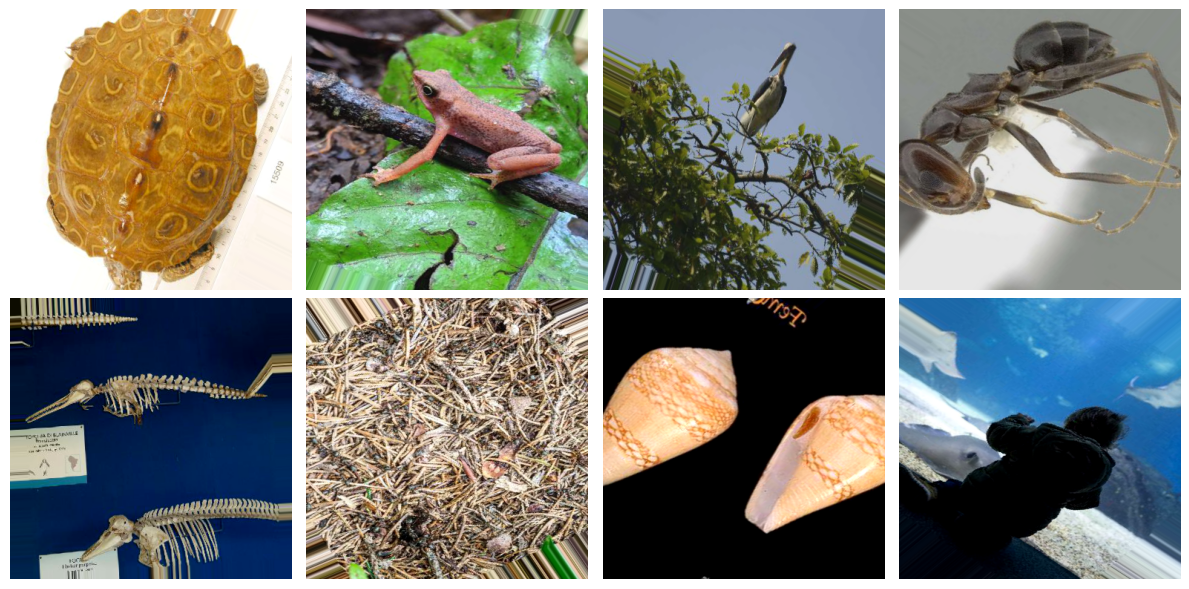

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1745788590.395171    7478 service.cc:146] XLA service 0x7e42900147a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745788590.395193    7478 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-27 22:16:31.067471: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-27 22:16:33.416741: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-27 22:16:39.026565: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-27 22:16:42.161558: E external/local_xla/xla/service/slow_operation_alarm.cc:65] 

157/255 ━━━━━━━━━━━━━━━━━━━━ 1:57 1s/step - accuracy: 0.8504 - auc: 0.4932 - loss: 0.5174 - precision: 0.9299 - recall: 0.9086

2025-04-27 22:20:33.834359: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.95GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8734 - auc: 0.4959 - loss: 0.4586 - precision: 0.9293 - recall: 0.9356

2025-04-27 22:23:55.278484: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng42{k2=2,k4=2,k5=0,k6=0,k7=0} for conv (f32[31,24,190,190]{3,2,1,0}, u8[0]{0}) custom-call(f32[31,24,190,190]{3,2,1,0}, f32[24,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=24, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-04-27 22:23:55.423408: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.145044123s
Trying algorithm eng42{k2=2,k4=2,k5=0,k6=0,k7=0} for conv (f32[31,24,190,190]{3,2,1,0}, u8[0]{0}) custom-call(f32[31,24,190,190]{3,2,1,0}, f32[24,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=24, custom_ca

255/255 ━━━━━━━━━━━━━━━━━━━━ 485s 2s/step - accuracy: 0.8735 - auc: 0.4959 - loss: 0.4582 - precision: 0.9293 - recall: 0.9358 - val_accuracy: 0.9291 - val_auc: 0.5657 - val_loss: 0.3343 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 379s 1s/step - accuracy: 0.9302 - auc: 0.5153 - loss: 0.2533 - precision: 0.9302 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc: 0.5114 - val_loss: 0.2888 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.9329 - auc: 0.5167 - loss: 0.2460 - precision: 0.9329 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc: 0.5000 - val_loss: 0.5532 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.9321 - auc: 0.5330 - loss: 0.2473 - precision: 0.9322 - recall: 0.9998 - val_accuracy: 0.9291 - val_auc: 0.5914 - val_loss: 0.2570 - val_precis

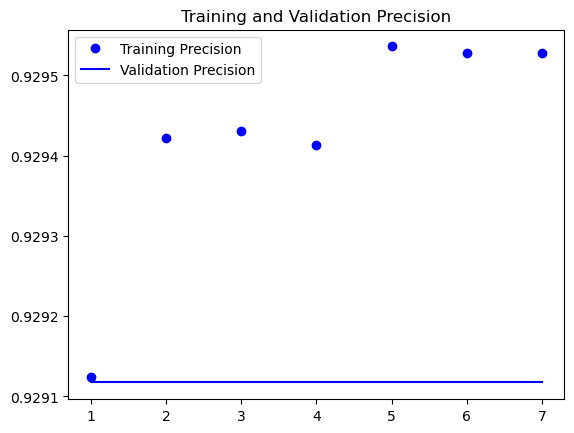

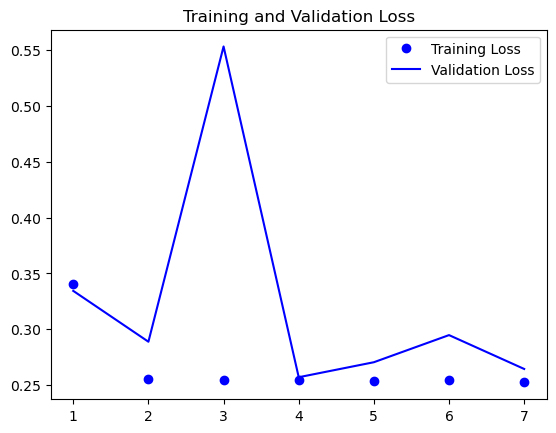

Saved current model as new baseline


In [7]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
    ,model_name='efficientnetb4'
)

#### Focal Loss

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


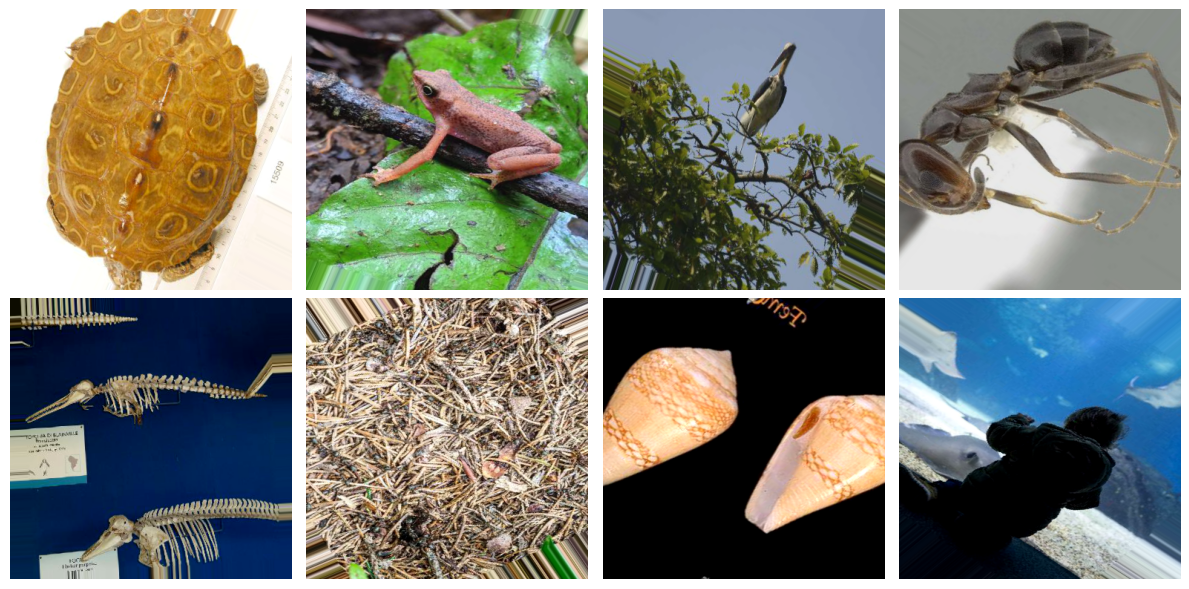

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.8640 - auc_1: 0.4813 - loss: 0.0087 - precision: 0.9263 - recall: 0.9258 - val_accuracy: 0.9291 - val_auc_1: 0.4973 - val_loss: 0.0062 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.9271 - auc_1: 0.5053 - loss: 0.0060 - precision: 0.9271 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_1: 0.4756 - val_loss: 0.0059 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.9304 - auc_1: 0.4746 - loss: 0.0059 - precision: 0.9305 - recall: 0.9998 - val_accuracy: 0.9291 - val_auc_1: 0.5068 - val_loss: 0.0059 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9296 - auc_1: 0.4925 - loss: 0.0059 - precision: 0.9296 - recall: 1.0000
Epoch 4: ReduceLROnPlateau reducing learning rate

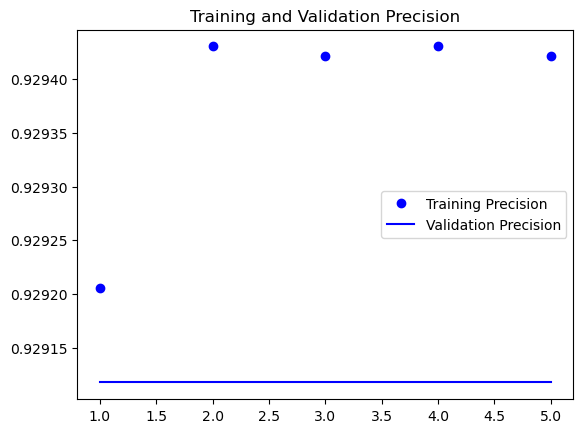

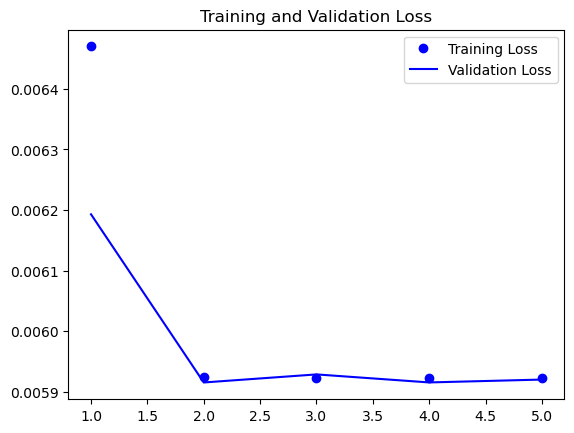

Current model not better than baseline


In [8]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='focal'
    ,epochs=10
    ,type='original'
    ,model_name='efficientnetb4'
)

The binary crossentropy loss function performed better and so this is the loss function we will be using from now on.

### Model with Regularization

In this section we add L2 regularization to our model and test if it improves the model

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


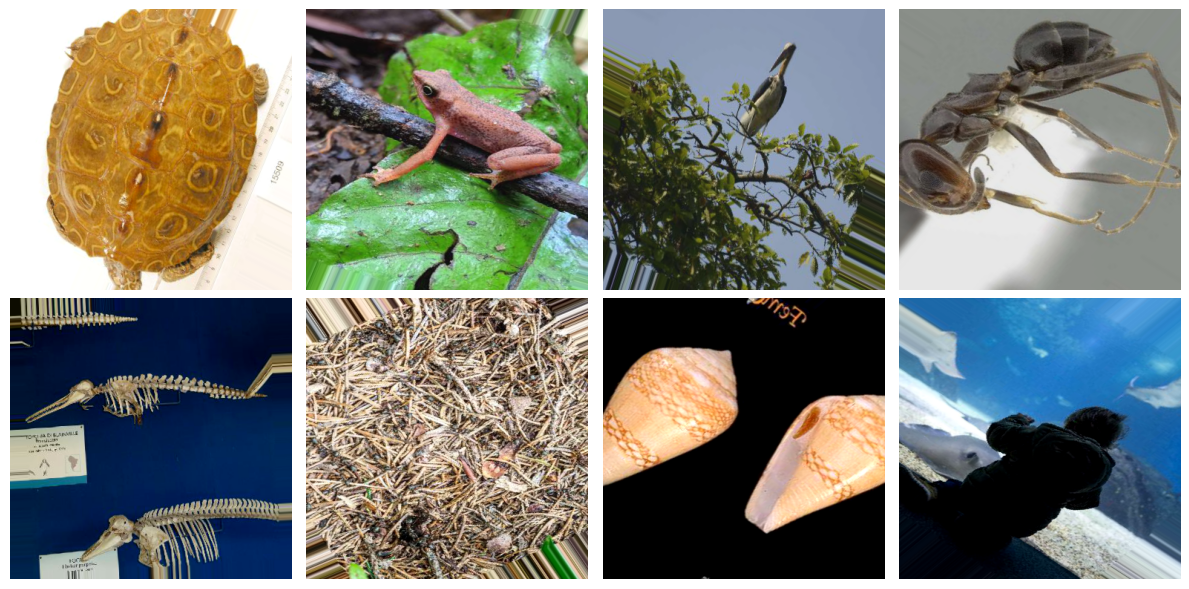

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 480s 2s/step - accuracy: 0.8748 - auc_2: 0.4907 - loss: 0.5572 - precision: 0.9286 - recall: 0.9381 - val_accuracy: 0.9291 - val_auc_2: 0.5315 - val_loss: 0.2772 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 417s 2s/step - accuracy: 0.9293 - auc_2: 0.5252 - loss: 0.2626 - precision: 0.9293 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_2: 0.5434 - val_loss: 0.2584 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.9358 - auc_2: 0.5301 - loss: 0.2411 - precision: 0.9358 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_2: 0.4642 - val_loss: 0.2669 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9302 - auc_2: 0.5243 - loss: 0.2579 - precision: 0.9302 - recall: 1.0000
Epoch 4: ReduceLROnPlateau reducing learning rate

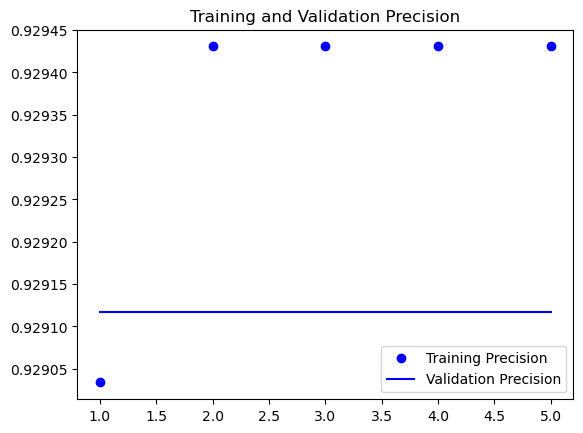

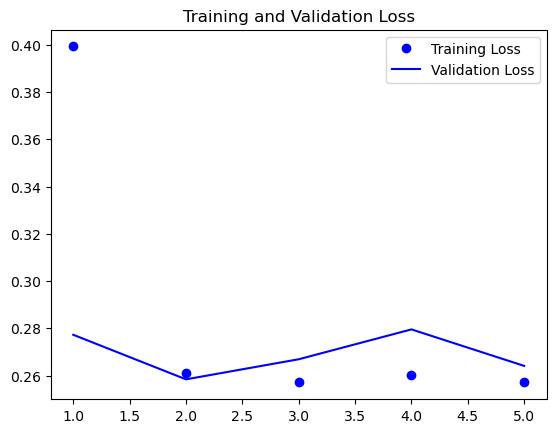

Current model not better than baseline


In [9]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=True
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
    ,model_name='efficientnetb4'
)

Regularization did not improve the model.

### Model with Dropout

In this section we add a dropout layer to the model and test if it improves the results.

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


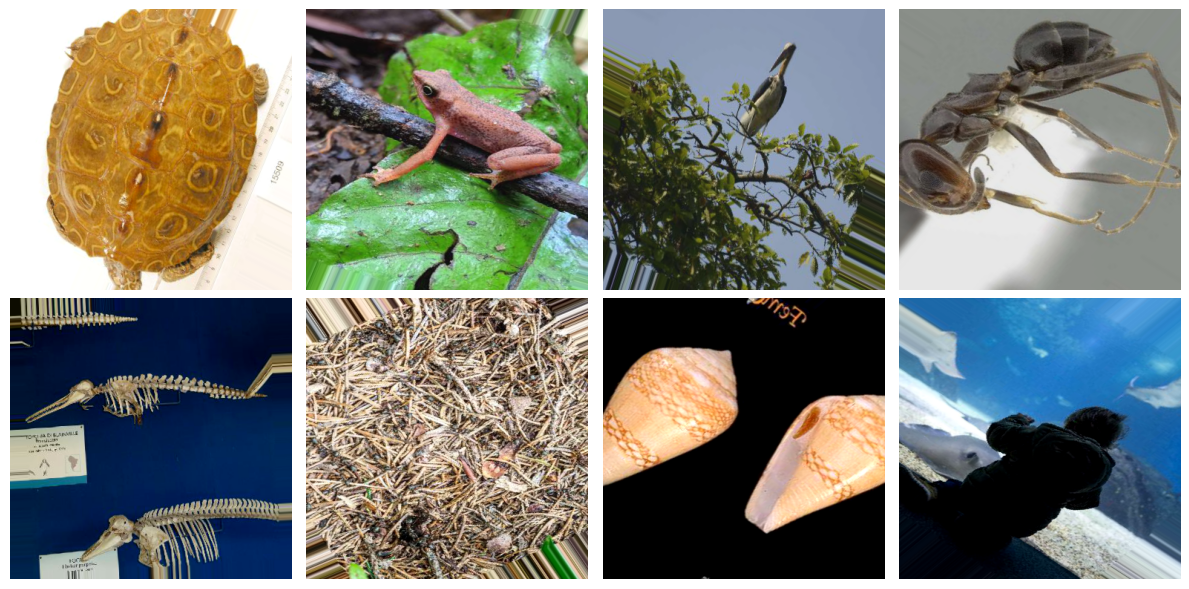

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.7681 - auc_3: 0.4782 - loss: 0.5282 - precision: 0.9297 - recall: 0.8135 - val_accuracy: 0.9291 - val_auc_3: 0.5312 - val_loss: 0.2728 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step - accuracy: 0.9301 - auc_3: 0.5202 - loss: 0.2628 - precision: 0.9302 - recall: 0.9998 - val_accuracy: 0.9291 - val_auc_3: 0.5196 - val_loss: 0.2581 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 418s 2s/step - accuracy: 0.9226 - auc_3: 0.5032 - loss: 0.2843 - precision: 0.9230 - recall: 0.9995 - val_accuracy: 0.9291 - val_auc_3: 0.5109 - val_loss: 0.2922 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9322 - auc_3: 0.5048 - loss: 0.2563 - precision: 0.9322 - recall: 1.0000
Epoch 4: ReduceLROnPlateau reducing learning rate

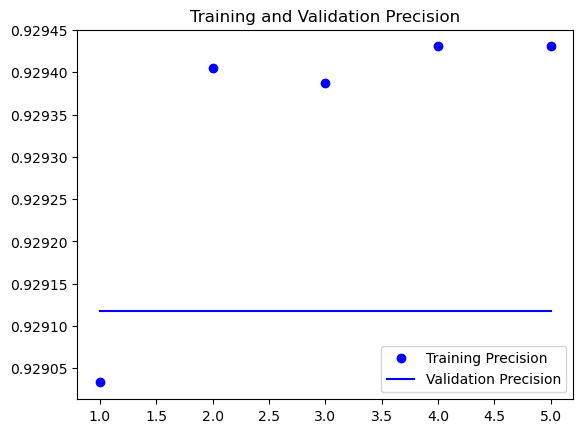

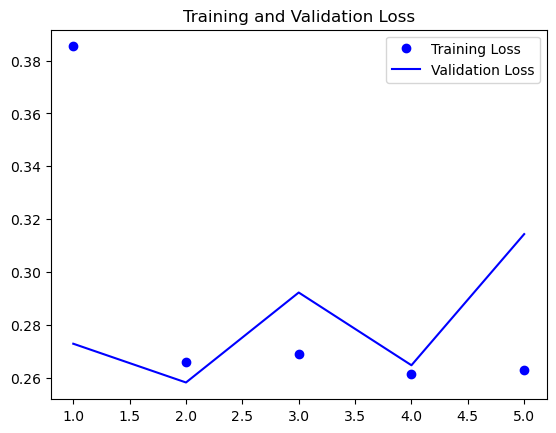

Current model not better than baseline


In [10]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=True
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
    ,model_name='efficientnetb4'
)

The dropout layer did not improve the model.

Now, we will attempt to transform the input images and recheck the model.